# Phase 3 v3: Two-Stage Model Training

---
## 1. Setup

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'torch', 'numpy', 'pandas', 'scikit-learn', 'matplotlib', 'seaborn'])
print('Ready.')

Ready.


In [2]:
import os, json, pickle, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
warnings.filterwarnings('ignore'); sns.set_style('whitegrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [3]:
DATA_DIR = '/home/sagemaker-user/exam_proctoring_dataset'
OUTPUT_DIR = os.path.join(DATA_DIR, 'training_outputs')
FEATURES_CHECKPOINT = os.path.join(OUTPUT_DIR, 'features_v2_checkpoint.pkl')
SPLIT_CHECKPOINT = os.path.join(OUTPUT_DIR, 'split_v2_checkpoint.pkl')

# Stage 1 paths
S1_MODEL_PATH = os.path.join(OUTPUT_DIR, 'stage1_best.pth')
S1_SCALER_PATH = os.path.join(OUTPUT_DIR, 'stage1_scaler.pkl')

# Stage 2 paths
S2_MODEL_PATH = os.path.join(OUTPUT_DIR, 'stage2_best.pth')
S2_SCALER_PATH = os.path.join(OUTPUT_DIR, 'stage2_scaler.pkl')

INFERENCE_PKG_PATH = os.path.join(OUTPUT_DIR, 'inference_package_v2.pth')

H1=128; H2=64; DROP=0.3; LR=1e-3; BS=64; EPOCHS=150; PAT=20
SEED=42; np.random.seed(SEED); torch.manual_seed(SEED)

SUSPICIOUS_CLASSES = ['looking_sideways','leaning_to_neighbor','using_phone',
                      'talking_to_neighbor','looking_down','passing_note']

def save_ckpt(d, p):
    with open(p,'wb') as f: pickle.dump(d,f)
    print(f'Saved: {p}')
def load_ckpt(p):
    if os.path.exists(p):
        with open(p,'rb') as f: d=pickle.load(f)
        print(f'CHECKPOINT: {p}'); return d
    return None

---
## 2. Load Features

In [4]:
cached = load_ckpt(FEATURES_CHECKPOINT)
if cached is None: raise FileNotFoundError('Run Phase 2 v2 first!')

all_features = cached['features']
all_labels_7 = cached['labels_7class']
all_labels_2 = cached['labels_binary']
all_meta = cached['meta']
FEAT_NAMES = cached['feature_names']
FULL_FEAT_NAMES = cached['full_feature_names']
NUM_FEATURES = len(FULL_FEAT_NAMES)

print(f'Windows: {len(all_features)}, Features: {NUM_FEATURES}')
print(f'\nBinary: {dict(zip(*np.unique(all_labels_2, return_counts=True)))}')
print(f'\n7-class:')
for l, c in zip(*np.unique(all_labels_7, return_counts=True)):
    print(f'  {l}: {c} ({c/len(all_labels_7)*100:.1f}%)')

CHECKPOINT: /home/sagemaker-user/exam_proctoring_dataset/training_outputs/features_v2_checkpoint.pkl
Windows: 5880, Features: 78

Binary: {'normal': 4208, 'suspicious': 1672}

7-class:
  leaning_to_neighbor: 326 (5.5%)
  looking_down: 206 (3.5%)
  looking_sideways: 258 (4.4%)
  normal: 4208 (71.6%)
  passing_note: 178 (3.0%)
  talking_to_neighbor: 303 (5.2%)
  using_phone: 401 (6.8%)


---
## 3. Split Data

In [5]:

cached_split = load_ckpt(SPLIT_CHECKPOINT)

def stratified_scenario_split(meta_df, seed=SEED):
    """Split scenario_id by original_behavior so each class is represented in train/val/test."""
    rng = np.random.default_rng(seed)
    scenario_df = meta_df[['scenario_id', 'original_behavior']].drop_duplicates().copy()

    train_ids, val_ids, test_ids = [], [], []

    for cls in sorted(scenario_df['original_behavior'].unique()):
        cls_ids = scenario_df.loc[scenario_df['original_behavior'] == cls, 'scenario_id'].unique().tolist()
        cls_ids = list(cls_ids)
        rng.shuffle(cls_ids)
        n = len(cls_ids)

        if n < 3:
            raise ValueError(f"Need at least 3 scenarios for class '{cls}' to make train/val/test splits. Found {n}.")

        n_train = max(1, int(round(n * 0.70)))
        n_val = max(1, int(round(n * 0.15)))
        n_test = n - n_train - n_val

        # Ensure all 3 splits are non-empty
        if n_test < 1:
            if n_train > n_val:
                n_train -= 1
            else:
                n_val -= 1
            n_test = n - n_train - n_val
        if n_val < 1:
            n_val = 1
            n_train = max(1, n - n_val - 1)
            n_test = n - n_train - n_val

        train_ids.extend(cls_ids[:n_train])
        val_ids.extend(cls_ids[n_train:n_train + n_val])
        test_ids.extend(cls_ids[n_train + n_val:])

    return np.array(train_ids), np.array(val_ids), np.array(test_ids)

if cached_split is not None:
    split = cached_split
else:
    meta_df = pd.DataFrame(all_meta)
    tr_s, va_s, te_s = stratified_scenario_split(meta_df, seed=SEED)

    tr_m = meta_df['scenario_id'].isin(tr_s).values
    va_m = meta_df['scenario_id'].isin(va_s).values
    te_m = meta_df['scenario_id'].isin(te_s).values

    split = {
        'train_mask': tr_m, 'val_mask': va_m, 'test_mask': te_m,
        'train_scenarios': tr_s, 'val_scenarios': va_s, 'test_scenarios': te_s
    }
    save_ckpt(split, SPLIT_CHECKPOINT)

tr_m = split['train_mask']; va_m = split['val_mask']; te_m = split['test_mask']
print(f'Train: {tr_m.sum()}, Val: {va_m.sum()}, Test: {te_m.sum()}')

# Sanity check: every original behaviour should appear in every split
meta_df = pd.DataFrame(all_meta)
for split_name, mask in [('train', tr_m), ('val', va_m), ('test', te_m)]:
    present = sorted(meta_df.loc[mask & meta_df['is_target'], 'original_behavior'].unique())
    print(f'{split_name.title()} target classes: {present}')


Saved: /home/sagemaker-user/exam_proctoring_dataset/training_outputs/split_v2_checkpoint.pkl
Train: 4120, Val: 920, Test: 840
Train target classes: ['leaning_to_neighbor', 'looking_down', 'looking_sideways', 'normal', 'passing_note', 'talking_to_neighbor', 'using_phone']
Val target classes: ['leaning_to_neighbor', 'looking_down', 'looking_sideways', 'normal', 'passing_note', 'talking_to_neighbor', 'using_phone']
Test target classes: ['leaning_to_neighbor', 'looking_down', 'looking_sideways', 'normal', 'passing_note', 'talking_to_neighbor', 'using_phone']


---
## 4. Stage 1 - Binary Classifier (Normal vs Suspicious)


In [6]:
# Prepare Stage 1 data
le1 = LabelEncoder(); le1.fit(['normal','suspicious'])
y1_all = le1.transform(all_labels_2)

sc1 = StandardScaler()
X1_tr = sc1.fit_transform(all_features[tr_m]).astype(np.float32)
X1_va = sc1.transform(all_features[va_m]).astype(np.float32)
X1_te = sc1.transform(all_features[te_m]).astype(np.float32)
y1_tr=y1_all[tr_m]; y1_va=y1_all[va_m]; y1_te=y1_all[te_m]

save_ckpt(sc1, S1_SCALER_PATH)

print(f'Stage 1 — Train: {len(X1_tr)}')
print(f'  normal: {(y1_tr==0).sum()}, suspicious: {(y1_tr==1).sum()}')
print(f'  ratio: {(y1_tr==0).sum() / max((y1_tr==1).sum(), 1):.1f}:1')

# Balanced sampler
cc1 = np.bincount(y1_tr, minlength=2)
sw1 = (1.0/np.maximum(cc1,1))[y1_tr]
sw1 = sw1 / sw1.sum()
sampler1 = WeightedRandomSampler(sw1, len(sw1), replacement=True)

dl1_tr = DataLoader(TensorDataset(torch.FloatTensor(X1_tr), torch.LongTensor(y1_tr)), batch_size=BS, sampler=sampler1)
dl1_va = DataLoader(TensorDataset(torch.FloatTensor(X1_va), torch.LongTensor(y1_va)), batch_size=BS, shuffle=False)
dl1_te = DataLoader(TensorDataset(torch.FloatTensor(X1_te), torch.LongTensor(y1_te)), batch_size=BS, shuffle=False)

Saved: /home/sagemaker-user/exam_proctoring_dataset/training_outputs/stage1_scaler.pkl
Stage 1 — Train: 4120
  normal: 2913, suspicious: 1207
  ratio: 2.4:1


In [7]:
class Classifier(nn.Module):
    def __init__(self, inp, h1, h2, out, drop=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.BatchNorm1d(inp), nn.Linear(inp, h1), nn.ReLU(), nn.Dropout(drop),
            nn.BatchNorm1d(h1), nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(drop),
            nn.Linear(h2, out))
    def forward(self, x): return self.net(x)


def train_model(model, train_dl, val_dl, n_cls, save_path, max_ep=EPOCHS, patience=PAT):
    cc = np.zeros(n_cls)
    for _, yb in train_dl: 
        for y in yb.numpy(): cc[y] += 1
    lw = 1.0/np.maximum(cc,1); lw = lw/lw.sum()*n_cls
    criterion = nn.CrossEntropyLoss(weight=torch.FloatTensor(lw).to(device))
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)
    
    hist = {'t_loss':[],'v_loss':[],'t_f1':[],'v_f1':[]}
    best_f1 = 0; pat_ctr = 0
    
    for ep in range(max_ep):
        model.train(); tl,tp,tt = [],[],[]
        for xb, yb in train_dl:
            xb,yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(); out=model(xb); loss=criterion(out,yb)
            loss.backward(); optimizer.step()
            tl.append(loss.item()); tp.extend(out.argmax(1).cpu().numpy()); tt.extend(yb.cpu().numpy())
        
        model.eval(); vl,vp,vt = [],[],[]
        with torch.no_grad():
            for xb,yb in val_dl:
                xb,yb=xb.to(device),yb.to(device); out=model(xb); loss=criterion(out,yb)
                vl.append(loss.item()); vp.extend(out.argmax(1).cpu().numpy()); vt.extend(yb.cpu().numpy())
        
        t_f1=f1_score(tt,tp,average='macro'); v_f1=f1_score(vt,vp,average='macro')
        hist['t_loss'].append(np.mean(tl)); hist['v_loss'].append(np.mean(vl))
        hist['t_f1'].append(t_f1); hist['v_f1'].append(v_f1)
        
        mk=''
        if v_f1 > best_f1:
            best_f1=v_f1; pat_ctr=0; mk=' *'
            torch.save({'epoch':ep,'state':model.state_dict(),'v_f1':v_f1}, save_path)
        else: pat_ctr += 1
        
        if (ep+1)%10==0 or mk:
            print(f'  Ep {ep+1:>4}: TrF1={t_f1:.3f} VaF1={v_f1:.3f} TrL={np.mean(tl):.4f} VaL={np.mean(vl):.4f}{mk}')
        
        scheduler.step(v_f1)
        if pat_ctr >= patience:
            print(f'  Early stopping at epoch {ep+1}'); break
    
    print(f'  Best val F1: {best_f1:.4f}')
    return hist, best_f1

print('Classifier and training function ready.')

Classifier and training function ready.


In [8]:
# Train Stage 1
print('='*50)
print('STAGE 1: Normal vs Suspicious')
print('='*50)

model1 = Classifier(NUM_FEATURES, H1, H2, 2, DROP).to(device)
print(f'Parameters: {sum(p.numel() for p in model1.parameters()):,}')

hist1, best_f1_s1 = train_model(model1, dl1_tr, dl1_va, 2, S1_MODEL_PATH)

STAGE 1: Normal vs Suspicious
Parameters: 18,910
  Ep    1: TrF1=0.671 VaF1=0.607 TrL=0.6152 VaL=0.6393 *
  Ep    2: TrF1=0.732 VaF1=0.661 TrL=0.5525 VaL=0.5786 *
  Ep    4: TrF1=0.772 VaF1=0.672 TrL=0.4898 VaL=0.5829 *
  Ep    5: TrF1=0.780 VaF1=0.698 TrL=0.4746 VaL=0.5679 *
  Ep    7: TrF1=0.797 VaF1=0.698 TrL=0.4437 VaL=0.5688 *
  Ep    8: TrF1=0.812 VaF1=0.707 TrL=0.4313 VaL=0.5536 *
  Ep   10: TrF1=0.808 VaF1=0.703 TrL=0.4146 VaL=0.5686
  Ep   11: TrF1=0.810 VaF1=0.718 TrL=0.4121 VaL=0.5606 *
  Ep   20: TrF1=0.852 VaF1=0.698 TrL=0.3333 VaL=0.6348
  Ep   30: TrF1=0.883 VaF1=0.694 TrL=0.2794 VaL=0.6600
  Early stopping at epoch 31
  Best val F1: 0.7180


### Stage 1 - Training Curves

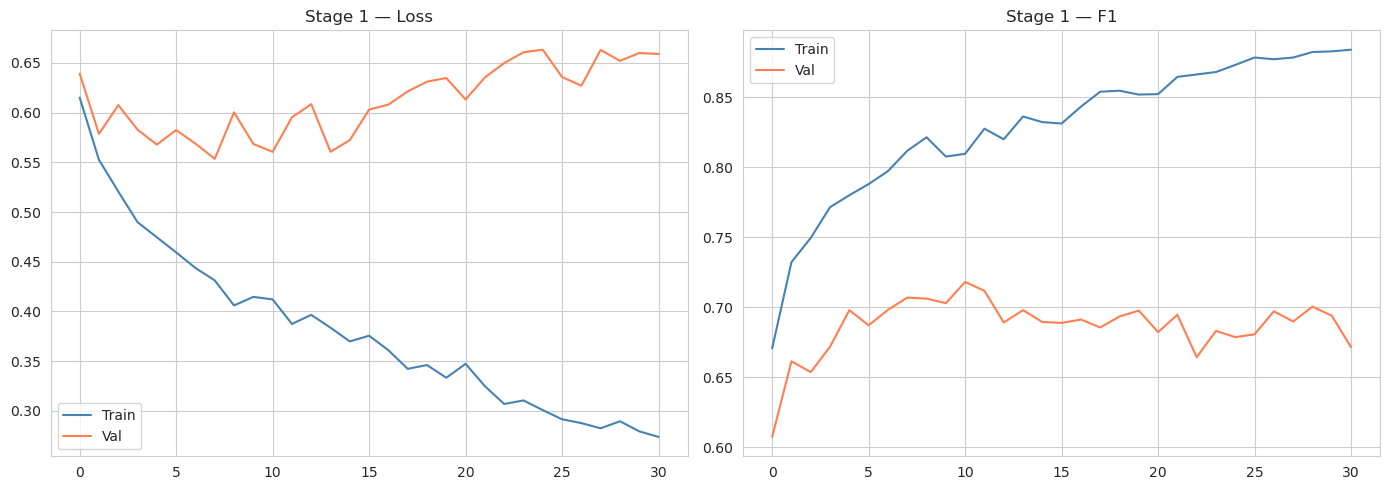

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist1['t_loss'], label='Train', color='steelblue')
axes[0].plot(hist1['v_loss'], label='Val', color='coral')
axes[0].set_title('Stage 1 — Loss'); axes[0].legend()
axes[1].plot(hist1['t_f1'], label='Train', color='steelblue')
axes[1].plot(hist1['v_f1'], label='Val', color='coral')
axes[1].set_title('Stage 1 — F1'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_stage1_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### Stage 1 - Test Evaluation

Loaded Stage 1 from epoch 11 (F1=0.7180)

STAGE 1 TEST RESULTS
Accuracy: 0.7202
F1: 0.6877

              precision    recall  f1-score   support

      normal      0.849     0.736     0.788       595
  suspicious      0.515     0.682     0.587       245

    accuracy                          0.720       840
   macro avg      0.682     0.709     0.688       840
weighted avg      0.752     0.720     0.730       840



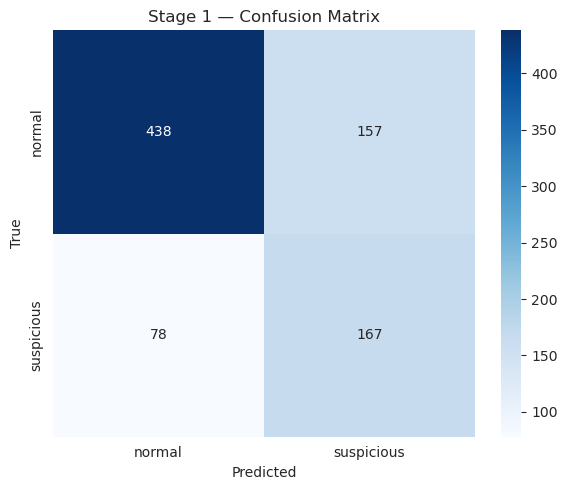

In [10]:

ckpt1 = torch.load(S1_MODEL_PATH, map_location=device)
model1.load_state_dict(ckpt1['state'])
print(f'Loaded Stage 1 from epoch {ckpt1["epoch"]+1} (F1={ckpt1["v_f1"]:.4f})')

model1.eval(); p1,t1,pr1 = [],[],[]
with torch.no_grad():
    for xb,yb in dl1_te:
        out=model1(xb.to(device)); probs=torch.softmax(out,1)
        p1.extend(out.argmax(1).cpu().numpy()); t1.extend(yb.numpy()); pr1.extend(probs.cpu().numpy())
p1=np.array(p1); t1=np.array(t1)

print(f'\nSTAGE 1 TEST RESULTS')
print(f'Accuracy: {accuracy_score(t1,p1):.4f}')
print(f'F1: {f1_score(t1,p1,average="macro"):.4f}')
print(f'\n{classification_report(t1, p1, labels=np.arange(len(le1.classes_)), target_names=le1.classes_, digits=3, zero_division=0)}')

cm1 = confusion_matrix(t1, p1, labels=np.arange(len(le1.classes_)))
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', xticklabels=le1.classes_, yticklabels=le1.classes_, ax=ax)
ax.set_title('Stage 1 — Confusion Matrix'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_stage1_cm.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 5. Stage 2 - Suspicious Subtype Classifier


In [11]:
# Filter to suspicious-only windows
sus_mask = all_labels_2 == 'suspicious'
X2_all = all_features[sus_mask]
y2_all_str = all_labels_7[sus_mask]  # 6 suspicious classes

le2 = LabelEncoder(); le2.fit(SUSPICIOUS_CLASSES)
y2_all = le2.transform(y2_all_str)

# Use same scenario split
meta_df = pd.DataFrame(all_meta)
sids_sus = meta_df.loc[sus_mask, 'scenario_id'].values
tr2 = np.isin(sids_sus, split['train_scenarios'])
va2 = np.isin(sids_sus, split['val_scenarios'])
te2 = np.isin(sids_sus, split['test_scenarios'])

sc2 = StandardScaler()
X2_tr = sc2.fit_transform(X2_all[tr2]).astype(np.float32)
X2_va = sc2.transform(X2_all[va2]).astype(np.float32)
X2_te = sc2.transform(X2_all[te2]).astype(np.float32)
y2_tr=y2_all[tr2]; y2_va=y2_all[va2]; y2_te=y2_all[te2]

save_ckpt(sc2, S2_SCALER_PATH)

print(f'Stage 2 — suspicious windows only')
print(f'Train: {len(X2_tr)}, Val: {len(X2_va)}, Test: {len(X2_te)}')
print(f'\nTrain distribution:')
for i, n in enumerate(le2.classes_):
    print(f'  {n}: {(y2_tr==i).sum()}')

# Balanced sampler
cc2 = np.bincount(y2_tr, minlength=6)
sw2 = (1.0/np.maximum(cc2,1))[y2_tr]; sw2 = sw2/sw2.sum()
sampler2 = WeightedRandomSampler(sw2, len(sw2), replacement=True)

dl2_tr = DataLoader(TensorDataset(torch.FloatTensor(X2_tr), torch.LongTensor(y2_tr)), batch_size=BS, sampler=sampler2)
dl2_va = DataLoader(TensorDataset(torch.FloatTensor(X2_va), torch.LongTensor(y2_va)), batch_size=BS, shuffle=False)
dl2_te = DataLoader(TensorDataset(torch.FloatTensor(X2_te), torch.LongTensor(y2_te)), batch_size=BS, shuffle=False)

Saved: /home/sagemaker-user/exam_proctoring_dataset/training_outputs/stage2_scaler.pkl
Stage 2 — suspicious windows only
Train: 1207, Val: 220, Test: 245

Train distribution:
  leaning_to_neighbor: 248
  looking_down: 141
  looking_sideways: 192
  passing_note: 123
  talking_to_neighbor: 221
  using_phone: 282


In [12]:
print('='*50)
print('STAGE 2: Suspicious Subtype Classification')
print('='*50)

model2 = Classifier(NUM_FEATURES, H1, H2, 6, DROP).to(device)
print(f'Parameters: {sum(p.numel() for p in model2.parameters()):,}')

hist2, best_f1_s2 = train_model(model2, dl2_tr, dl2_va, 6, S2_MODEL_PATH)

STAGE 2: Suspicious Subtype Classification
Parameters: 19,170
  Ep    1: TrF1=0.323 VaF1=0.264 TrL=1.6646 VaL=1.6812 *
  Ep    2: TrF1=0.527 VaF1=0.349 TrL=1.3739 VaL=1.5350 *
  Ep    3: TrF1=0.595 VaF1=0.391 TrL=1.1438 VaL=1.4148 *
  Ep    4: TrF1=0.656 VaF1=0.394 TrL=0.9534 VaL=1.3733 *
  Ep    5: TrF1=0.712 VaF1=0.418 TrL=0.8195 VaL=1.3483 *
  Ep    6: TrF1=0.746 VaF1=0.475 TrL=0.7252 VaL=1.2864 *
  Ep   10: TrF1=0.813 VaF1=0.494 TrL=0.5298 VaL=1.4145 *
  Ep   11: TrF1=0.842 VaF1=0.496 TrL=0.4702 VaL=1.4682 *
  Ep   13: TrF1=0.851 VaF1=0.502 TrL=0.4245 VaL=1.5264 *
  Ep   16: TrF1=0.859 VaF1=0.529 TrL=0.3894 VaL=1.5709 *
  Ep   17: TrF1=0.861 VaF1=0.538 TrL=0.3800 VaL=1.5465 *
  Ep   20: TrF1=0.889 VaF1=0.502 TrL=0.3205 VaL=1.5917
  Ep   30: TrF1=0.923 VaF1=0.529 TrL=0.2216 VaL=1.7808
  Ep   34: TrF1=0.934 VaF1=0.540 TrL=0.1962 VaL=1.8147 *
  Ep   40: TrF1=0.922 VaF1=0.485 TrL=0.2143 VaL=1.9241
  Ep   50: TrF1=0.943 VaF1=0.539 TrL=0.1652 VaL=1.8820
  Early stopping at epoch 54
  Bes

### Stage 2 - Training Curves

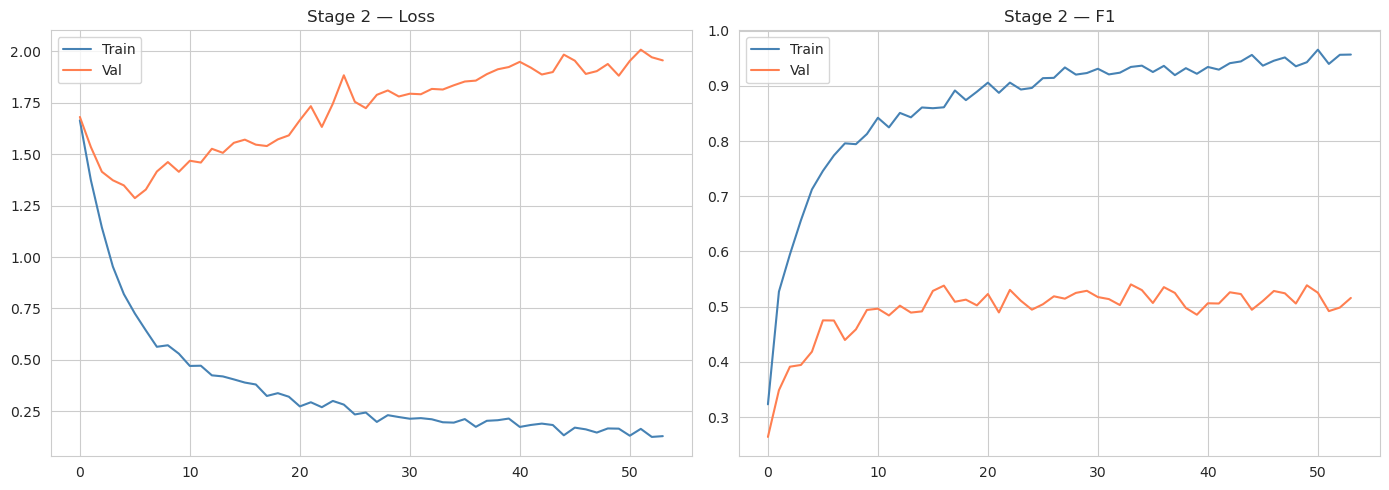

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(hist2['t_loss'], label='Train', color='steelblue')
axes[0].plot(hist2['v_loss'], label='Val', color='coral')
axes[0].set_title('Stage 2 — Loss'); axes[0].legend()
axes[1].plot(hist2['t_f1'], label='Train', color='steelblue')
axes[1].plot(hist2['v_f1'], label='Val', color='coral')
axes[1].set_title('Stage 2 — F1'); axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_stage2_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

### Stage 2 - Test Evaluation

Loaded Stage 2 from epoch 34 (F1=0.5402)

STAGE 2 TEST RESULTS (suspicious windows only)
Accuracy: 0.4408
F1: 0.4172

                     precision    recall  f1-score   support

leaning_to_neighbor      0.385     0.204     0.267        49
       looking_down      0.579     0.629     0.603        35
   looking_sideways      0.355     0.333     0.344        33
       passing_note      0.312     0.385     0.345        26
talking_to_neighbor      0.333     0.385     0.357        39
        using_phone      0.548     0.635     0.588        63

           accuracy                          0.441       245
          macro avg      0.419     0.428     0.417       245
       weighted avg      0.435     0.441     0.430       245



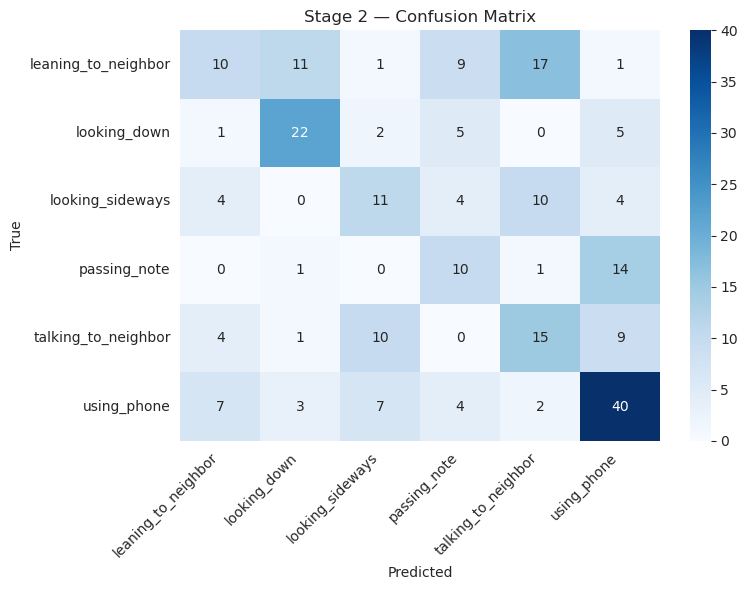

In [14]:

ckpt2 = torch.load(S2_MODEL_PATH, map_location=device)
model2.load_state_dict(ckpt2['state'])
print(f'Loaded Stage 2 from epoch {ckpt2["epoch"]+1} (F1={ckpt2["v_f1"]:.4f})')

model2.eval(); p2,t2 = [],[]
with torch.no_grad():
    for xb,yb in dl2_te:
        out=model2(xb.to(device))
        p2.extend(out.argmax(1).cpu().numpy()); t2.extend(yb.numpy())
p2=np.array(p2); t2=np.array(t2)

print(f'\nSTAGE 2 TEST RESULTS (suspicious windows only)')
print(f'Accuracy: {accuracy_score(t2,p2):.4f}')
print(f'F1: {f1_score(t2,p2,average="macro"):.4f}')
print(f'\n{classification_report(t2, p2, labels=np.arange(len(le2.classes_)), target_names=le2.classes_, digits=3, zero_division=0)}')

cm2 = confusion_matrix(t2, p2, labels=np.arange(len(le2.classes_)))
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=le2.classes_, yticklabels=le2.classes_, ax=ax)
ax.set_title('Stage 2 — Confusion Matrix'); ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_stage2_cm.png'), dpi=150, bbox_inches='tight')
plt.show()


---
## 6. Combined Pipeline Evaluation

In [15]:

# Run full pipeline on test set
le_7 = LabelEncoder(); le_7.fit(['normal'] + SUSPICIOUS_CLASSES)
y7_te = le_7.transform(all_labels_7[te_m])

# Stage 1: binary prediction on ALL test windows
model1.eval()
s1_preds = []
with torch.no_grad():
    for xb, _ in dl1_te:
        out = model1(xb.to(device))
        s1_preds.extend(out.argmax(1).cpu().numpy())
s1_preds = np.array(s1_preds)

# Stage 2: subtype prediction on windows Stage 1 called suspicious
sus_indices = np.where(s1_preds == le1.transform(['suspicious'])[0])[0]
print(f'Stage 1 flagged {len(sus_indices)} of {len(s1_preds)} test windows as suspicious')

# Build combined predictions
combined_preds = np.full(len(s1_preds), le_7.transform(['normal'])[0])  # default = normal

if len(sus_indices) > 0:
    X_sus = sc2.transform(all_features[te_m][sus_indices]).astype(np.float32)
    model2.eval()
    s2_preds = []
    with torch.no_grad():
        for i in range(0, len(X_sus), BS):
            xb = torch.FloatTensor(X_sus[i:i+BS]).to(device)
            out = model2(xb)
            s2_preds.extend(out.argmax(1).cpu().numpy())

    # Map Stage 2 class indices to 7-class indices
    for i, si in enumerate(sus_indices):
        sus_class_name = le2.classes_[s2_preds[i]]
        combined_preds[si] = le_7.transform([sus_class_name])[0]

# Evaluate combined
comb_acc = accuracy_score(y7_te, combined_preds)
comb_f1 = f1_score(y7_te, combined_preds, average='macro')

print(f'\n{"="*50}')
print(f'COMBINED PIPELINE — TEST RESULTS')
print(f'{"="*50}')
print(f'Accuracy: {comb_acc:.4f}')
print(f'Macro F1: {comb_f1:.4f}')
print(f'\n{classification_report(y7_te, combined_preds, labels=np.arange(len(le_7.classes_)), target_names=le_7.classes_, digits=3, zero_division=0)}')


Stage 1 flagged 324 of 840 test windows as suspicious

COMBINED PIPELINE — TEST RESULTS
Accuracy: 0.6071
Macro F1: 0.3242

                     precision    recall  f1-score   support

leaning_to_neighbor      0.188     0.184     0.186        49
       looking_down      0.288     0.429     0.345        35
   looking_sideways      0.179     0.152     0.164        33
             normal      0.849     0.736     0.788       595
       passing_note      0.173     0.346     0.231        26
talking_to_neighbor      0.231     0.385     0.288        39
        using_phone      0.241     0.302     0.268        63

           accuracy                          0.607       840
          macro avg      0.307     0.362     0.324       840
       weighted avg      0.665     0.607     0.631       840



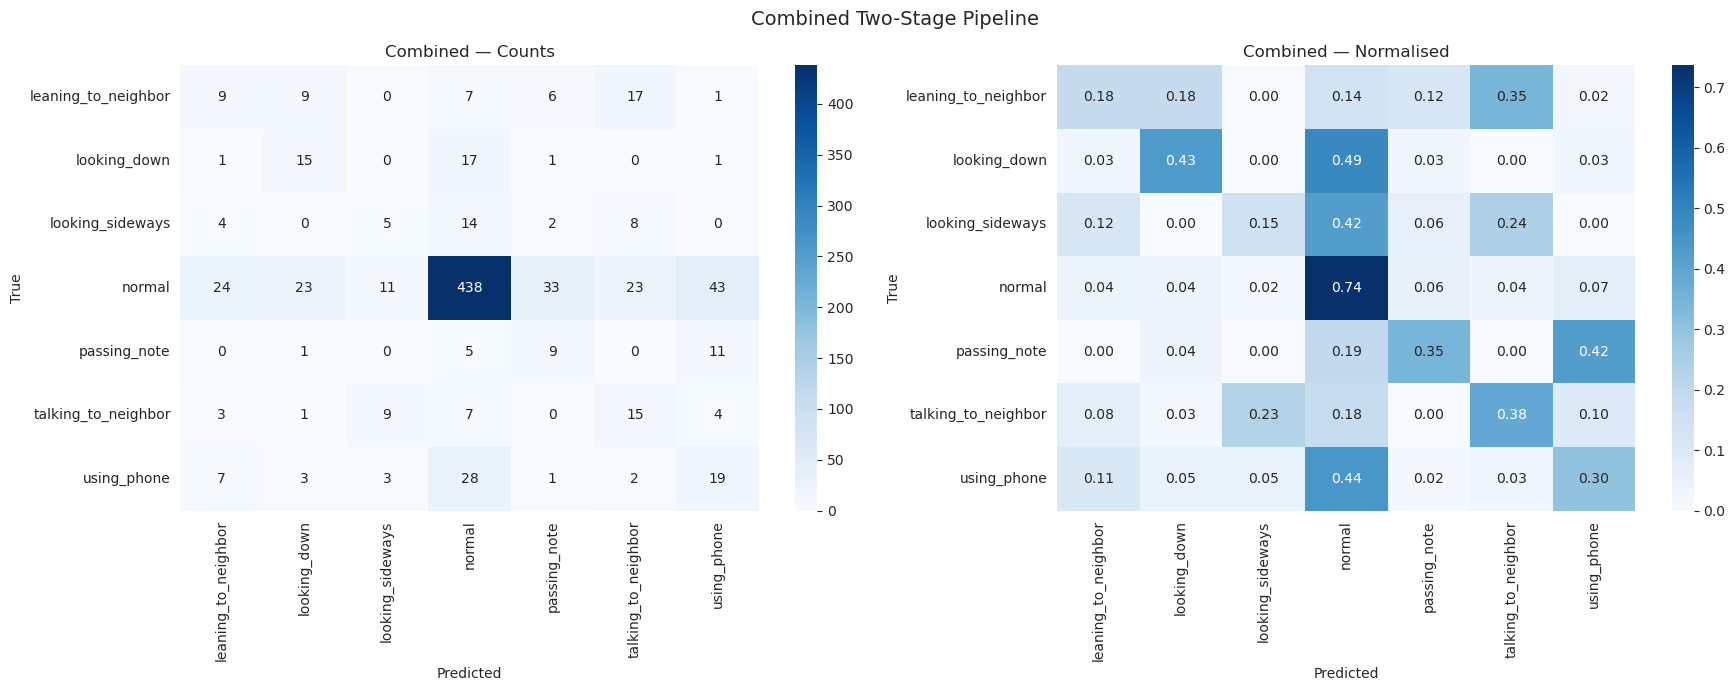

In [16]:

# Combined confusion matrix
cm_comb = confusion_matrix(y7_te, combined_preds, labels=np.arange(len(le_7.classes_)))
row_sums = cm_comb.sum(axis=1, keepdims=True)
cm_comb_n = np.divide(cm_comb.astype(float), row_sums, out=np.zeros_like(cm_comb, dtype=float), where=row_sums != 0)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
sns.heatmap(cm_comb, annot=True, fmt='d', cmap='Blues', xticklabels=le_7.classes_, yticklabels=le_7.classes_, ax=axes[0])
axes[0].set_title('Combined — Counts')
sns.heatmap(cm_comb_n, annot=True, fmt='.2f', cmap='Blues', xticklabels=le_7.classes_, yticklabels=le_7.classes_, ax=axes[1])
axes[1].set_title('Combined — Normalised')
for ax in axes: ax.set_ylabel('True'); ax.set_xlabel('Predicted')
plt.suptitle('Combined Two-Stage Pipeline', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_combined_cm.png'), dpi=150, bbox_inches='tight')
plt.show()


### Prediction Confidence

Correct: 510 / 840 (60.7%)


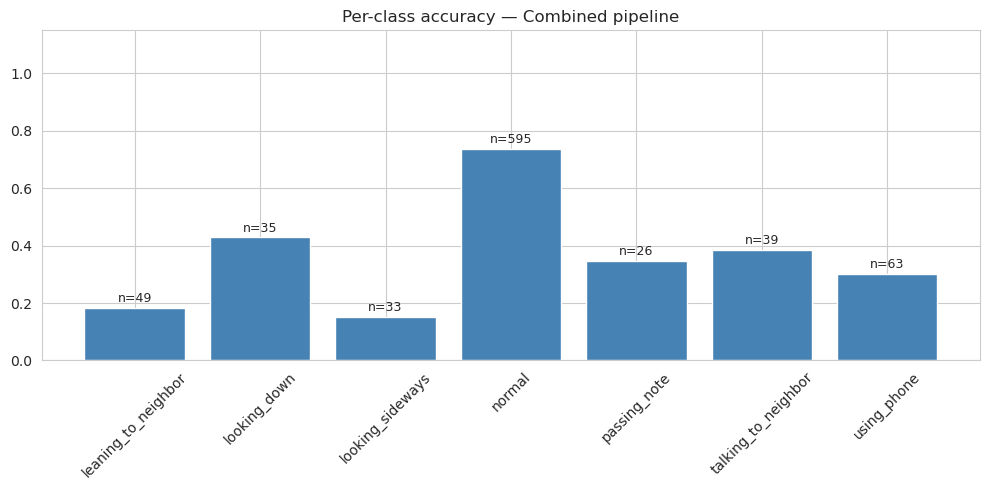

In [17]:
# Confidence analysis
correct = combined_preds == y7_te
print(f'Correct: {correct.sum()} / {len(correct)} ({correct.mean()*100:.1f}%)')

# Per-class accuracy
fig, ax = plt.subplots(figsize=(10, 5))
cls_accs = []
for i, n in enumerate(le_7.classes_):
    m = y7_te == i
    if m.sum() > 0:
        cls_accs.append((n, (combined_preds[m]==y7_te[m]).mean(), m.sum()))
names, accs, cnts = zip(*cls_accs)
bars = ax.bar(names, accs, color='steelblue', edgecolor='white')
for b, c in zip(bars, cnts):
    ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'n={c}', ha='center', fontsize=9)
ax.set_title('Per-class accuracy — Combined pipeline')
ax.set_ylim(0, 1.15); ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'v2_per_class_accuracy.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Export for Inference

In [18]:
pkg = {
    'stage1_state': model1.state_dict(),
    'stage2_state': model2.state_dict(),
    'model_config': {'input_dim':NUM_FEATURES,'hidden1':H1,'hidden2':H2,'dropout':DROP},
    'stage1_classes': list(le1.classes_),
    'stage2_classes': list(le2.classes_),
    'all_classes': ['normal'] + SUSPICIOUS_CLASSES,
    'feature_names': FEAT_NAMES,
    'full_feature_names': FULL_FEAT_NAMES,
    'window_size_sec': 3.0,
    'min_visibility': 0.5,
    'test_accuracy': float(comb_acc),
    'test_f1': float(comb_f1),
    'stage1_f1': float(best_f1_s1),
    'stage2_f1': float(best_f1_s2),
}
torch.save(pkg, INFERENCE_PKG_PATH)

print(f'Inference package: {INFERENCE_PKG_PATH}')
print(f'\nStage 1 F1: {best_f1_s1:.4f}')
print(f'Stage 2 F1: {best_f1_s2:.4f}')
print(f'Combined accuracy: {comb_acc:.4f}')
print(f'Combined F1: {comb_f1:.4f}')

print(f'\nAll outputs:')
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f'  {f} ({os.path.getsize(os.path.join(OUTPUT_DIR,f))/1024:.1f} KB)')

print(f'\nPhase 3 v2 complete!')

Inference package: /home/sagemaker-user/exam_proctoring_dataset/training_outputs/inference_package_v2.pth

Stage 1 F1: 0.7180
Stage 2 F1: 0.5402
Combined accuracy: 0.6071
Combined F1: 0.3242

All outputs:
  .ipynb_checkpoints (0.0 KB)
  active_segment.png (153.1 KB)
  best_model.pth (222.5 KB)
  confusion_matrix.png (142.5 KB)
  dataset_overview.png (94.0 KB)
  feature_distributions.png (172.6 KB)
  features_checkpoint.pkl (8928.6 KB)
  features_v2_checkpoint.pkl (2693.9 KB)
  final_model.pth (76.0 KB)
  inference_package.pth (79.6 KB)
  inference_package_v2.pth (167.1 KB)
  keypoint_trajectories.png (478.4 KB)
  label_encoder.pkl (0.8 KB)
  per_frame_features.png (624.3 KB)
  prediction_analysis.png (77.5 KB)
  scaler.pkl (2.0 KB)
  split_checkpoint.pkl (6399.5 KB)
  split_v2_checkpoint.pkl (18.6 KB)
  stage1_best.pth (80.8 KB)
  stage1_scaler.pkl (2.3 KB)
  stage2_best.pth (81.8 KB)
  stage2_scaler.pkl (2.3 KB)
  training_curves.png (81.2 KB)
  training_history.json (2.0 KB)
  v2_7cl